## 라이브러리 및 데이터 로드

필요한 모듈을 가져오고 데이터를 준비합니다.

In [19]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('skin_irritation_2Ddesc.csv')
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])
y = df['label']

In [20]:
X.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,100.076,114.104465,48,...,0,0,0,0,0,0,0,0,4,0
1,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,144.154,152.029586,52,...,1,0,0,0,0,0,0,0,0,0
2,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,164.119,186.161980,78,...,0,0,0,0,0,0,0,0,4,0
3,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,278.202,305.199094,122,...,0,0,0,0,0,0,0,0,0,0
4,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,116.075,130.099380,54,...,0,0,0,0,0,0,0,0,2,0


In [21]:
print(y.value_counts())

label
0    26
1    13
Name: count, dtype: int64


## 데이터 전처리

결측치를 처리하고 분산이 거의 없는 descriptor를 필터링합니다.

In [2]:
# 1. 결측치(NaN)를 각 컬럼의 평균값으로 대체 (SelectKBest 연산 오류 방지)
X = X.fillna(X.mean())

# 2. 표준편차(std)가 0.01 미만인 descriptor 제거
X = X.loc[:, X.std() >= 0.01]

print(f"표준편차 필터링 후 남은 변수 개수: {X.shape[1]}")

표준편차 필터링 후 남은 변수 개수: 152


## 데이터 스케일링 및 특성 선택 (Feature Selection)

MLP 알고리즘을 위해 스케일을 맞추고, 통계적으로 유의미한 변수 K개를 선택합니다.

In [3]:
# 1. StandardScaler를 이용한 정규화
X_scaled = StandardScaler().fit_transform(X)

# 2. SelectKBest를 이용해 모델에 사용할 특징 상위 10개 선택
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_scaled, y)

# 선택된 특성 이름 확인
selected_features = X.columns[selector.get_support()].tolist()
print(f"선택된 상위 10개 Feature:\n{selected_features}")

선택된 상위 10개 Feature:
['MinAbsEStateIndex', 'BertzCT', 'Chi0', 'Chi1', 'PEOE_VSA7', 'SlogP_VSA6', 'HeavyAtomCount', 'MolMR', 'fr_C_O_noCOO', 'fr_ester']


## 데이터 분할 및 단일 MLP 모델 학습

학습/테스트 세트로 나누고 기본적인 파라미터로 모델을 구성하여 결과를 확인합니다.

In [4]:
# 데이터 분할 (학습용 80%, 테스트용 20%)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# 단일 MLP 모델 학습 (은닉층 노드 10개, L2 규제 0.001)
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), alpha=0.001, max_iter=2000, random_state=42)
mlp_base.fit(X_train, y_train)

print(f"기본 모델 정확도: {mlp_base.score(X_test, y_test):.4f}")

기본 모델 정확도: 0.8750


## MLP 하이퍼파라미터 조정 및 성능 비교

MLPClassifier에서 성능에 직접적인 영향을 주는 주요 파라미터를 변경하며 성능이 어떻게 변하는지 확인합니다.

In [6]:
# 은닉층 구조(hidden_layer_sizes)와 규제 강도(alpha)에 따른 조합 성능 비교
configs = [
    {'hidden': (10,), 'alpha': 0.001},     # 1개 층 (노드 10), 약한 규제
    {'hidden': (50,), 'alpha': 0.01},      # 1개 층 (노드 50), 중간 규제
    {'hidden': (10, 5), 'alpha': 0.1}      # 2개 층 (노드 10, 5), 강한 규제
]

for cfg in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden'], 
        alpha=cfg['alpha'], 
        max_iter=2000, 
        random_state=42
    )
    mlp.fit(X_train, y_train)
    acc = mlp.score(X_test, y_test)
    
    # 수정된 부분: str(cfg['hidden'])을 사용하여 문자열로 변환 후 출력
    print(f"은닉층 구조: {str(cfg['hidden']):<7} | 규제(Alpha): {cfg['alpha']:<5} => 모델 정확도: {acc:.4f}")

은닉층 구조: (10,)   | 규제(Alpha): 0.001 => 모델 정확도: 0.8750
은닉층 구조: (50,)   | 규제(Alpha): 0.01  => 모델 정확도: 0.8750
은닉층 구조: (10, 5) | 규제(Alpha): 0.1   => 모델 정확도: 0.8750


## 라이브러리 및 데이터 로드

필요한 모듈을 가져오고 데이터를 준비합니다.

In [23]:
import pandas as pd

# 1. 데이터 로드 및 타겟 분리
df = pd.read_csv('skin_irritation_2Ddesc.csv')

# 문자열 컬럼과 정답(label) 제외
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])
y = df['label']

In [24]:
X.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,100.076,114.104465,48,...,0,0,0,0,0,0,0,0,4,0
1,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,144.154,152.029586,52,...,1,0,0,0,0,0,0,0,0,0
2,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,164.119,186.161980,78,...,0,0,0,0,0,0,0,0,4,0
3,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,278.202,305.199094,122,...,0,0,0,0,0,0,0,0,0,0
4,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,116.075,130.099380,54,...,0,0,0,0,0,0,0,0,2,0


In [25]:
print(y.value_counts())

label
0    26
1    13
Name: count, dtype: int64


## 데이터 전처리

결측치를 처리하고 분산이 거의 없는 descriptor를 필터링합니다.

In [26]:
# 2. 결측치 대체 및 표준편차 필터링

# 결측치(NaN)를 각 컬럼의 평균값으로 대체
X = X.fillna(X.mean())

# 표준편차가 0.01 이상인 변수만 유지
X = X.loc[:, X.std() >= 0.01]

print(f"전처리 후 남은 특성 개수: {X.shape[1]}")

전처리 후 남은 특성 개수: 152


## 데이터 스케일링 및 특성 선택 (Feature Selection)

MLP 알고리즘을 위해 스케일을 맞추고, 통계적으로 유의미한 변수 K개를 선택합니다.

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# 3. 데이터 정규화 및 피처 5개 선택
X_scaled = StandardScaler().fit_transform(X)

# k=5로 설정하여 상위 5개 특징 추출
selector = SelectKBest(f_classif, k=5)
X_selected = selector.fit_transform(X_scaled, y)

selected_features = X.columns[selector.get_support()].tolist()
print(f"선택된 5개 Feature:\n{selected_features}")

선택된 5개 Feature:
['MinAbsEStateIndex', 'Chi1', 'MolMR', 'fr_C_O_noCOO', 'fr_ester']


## 데이터 분할 및 단일 MLP 모델 학습

학습/테스트 세트로 나누고 기본적인 파라미터로 모델을 구성하여 결과를 확인합니다.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# 4. 학습/테스트 데이터 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# [MLPClassifier 핵심 조정 하이퍼파라미터 6개]
# 1. hidden_layer_sizes : 은닉층의 개수와 노드 수
# 2. alpha              : L2 규제 패널티 (과적합 방지)
# 3. activation         : 활성화 함수 ('relu', 'tanh' 등)
# 4. solver             : 최적화 알고리즘 ('adam', 'lbfgs' 등)
# 5. learning_rate_init : 초기 학습률
# 6. max_iter           : 학습 반복 횟수

print("데이터 분할 완료. 모델 학습 준비가 되었습니다.")

데이터 분할 완료. 모델 학습 준비가 되었습니다.


## MLP 하이퍼파라미터 조정 및 성능 비교

MLPClassifier에서 성능에 직접적인 영향을 주는 주요 파라미터를 변경하며 성능이 어떻게 변하는지 확인합니다.

In [29]:
# 5. 하이퍼파라미터 조합별 모델 성능 테스트
configs = [
    {'hidden': (10,), 'alpha': 0.001},    # 단일 층 (노드 10)
    {'hidden': (50,), 'alpha': 0.01},     # 단일 층 (노드 50)
    {'hidden': (10, 5), 'alpha': 0.1}     # 다중 층 (노드 10, 노드 5)
]

for cfg in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden'], 
        alpha=cfg['alpha'], 
        max_iter=2000, 
        random_state=42
    )
    mlp.fit(X_train, y_train)
    acc = mlp.score(X_test, y_test)
    
    # str()을 씌워 튜플 포맷팅 오류 방지
    print(f"은닉층 구조: {str(cfg['hidden']):<7} | 규제(Alpha): {cfg['alpha']:<5} => 정확도: {acc:.4f}")

은닉층 구조: (10,)   | 규제(Alpha): 0.001 => 정확도: 0.7500
은닉층 구조: (50,)   | 규제(Alpha): 0.01  => 정확도: 0.7500
은닉층 구조: (10, 5) | 규제(Alpha): 0.1   => 정확도: 0.7500


In [30]:
import pandas as pd
from IPython.display import display

configs = [
    {'hidden': (10,), 'alpha': 0.001},
    {'hidden': (50,), 'alpha': 0.01},
    {'hidden': (10, 5), 'alpha': 0.1},
    {'hidden': (10, 5), 'alpha': 0.001} # 최고 성능 조합 추가
]

# 결과를 저장할 빈 리스트 만들기
results = []

for cfg in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden'], 
        alpha=cfg['alpha'], 
        max_iter=2000, 
        random_state=42
    )
    mlp.fit(X_train, y_train)
    acc = mlp.score(X_test, y_test)
    
    # 결과를 리스트에 딕셔너리 형태로 저장
    results.append({
        '은닉층 구조': str(cfg['hidden']), 
        '규제(Alpha)': cfg['alpha'], 
        '정확도': acc
    })

# Pandas DataFrame으로 변환 후 깔끔한 표 형태로 출력 (정확도 높은 순 정렬)
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='정확도', ascending=False))

,은닉층 구조,규제(Alpha),정확도
0,"(10,)",0.001,0.750
1,"(50,)",0.010,0.750
2,"(10, 5)",0.100,0.750
3,"(10, 5)",0.001,0.625


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# 1. 업로드한 데이터 불러오기
df = pd.read_csv('skin_irritation_2Ddesc.csv')

# 2. 특징(X)과 타겟(y) 분리 (학습에 방해되는 문자열 컬럼 제외)
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])
y = df['label']

# 3. 모델 학습을 위한 필수 전처리
# 신경망 모델은 빈칸(NaN)과 데이터 크기(Scale)에 매우 민감합니다.
X = X.fillna(X.mean())                         # 빈칸을 평균값으로 채우기
X_scaled = StandardScaler().fit_transform(X)   # 데이터의 스케일을 통일(정규화)

# 4. 학습용 / 테스트용 데이터 나누기 (80% 학습, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. 기본 인공신경망(MLP) 모델 만들고 학습시키기
mlp_model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000, random_state=42)
mlp_model.fit(X_train, y_train)

# 6. 모델 정확도(Accuracy) 확인
accuracy = mlp_model.score(X_test, y_test)
print(f"▶ 1단계 완성! 기본 인공신경망 모델 정확도: {accuracy:.4f}")

▶ 1단계 완성! 기본 인공신경망 모델 정확도: 1.0000


In [35]:
X.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,100.076,114.104465,48,...,0,0,0,0,0,0,0,0,4,0
1,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,144.154,152.029586,52,...,1,0,0,0,0,0,0,0,0,0
2,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,164.119,186.161980,78,...,0,0,0,0,0,0,0,0,4,0
3,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,278.202,305.199094,122,...,0,0,0,0,0,0,0,0,0,0
4,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,116.075,130.099380,54,...,0,0,0,0,0,0,0,0,2,0


In [46]:
df

,Chemical_Name,standardized_smi,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Heptanal,CCCCCCC=O,1,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,...,0,0,0,0,0,0,0,0,4,0
1,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,...,1,0,0,0,0,0,0,0,0,0
2,Heptyl butyrate,CCCCCCCOC(=O)CCC,0,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,...,0,0,0,0,0,0,0,0,4,0
3,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,...,0,0,0,0,0,0,0,0,0,0
4,Methyl caproate,CCCCCC(=O)OC,0,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,...,0,0,0,0,0,0,0,0,2,0
5,1-(2-Isopropylphenyl)-1-phenyle- thane (Mixtur...,CC(C)c1ccccc1C(C)c1ccccc1,0,2.288241,2.288241,0.467407,0.467407,0.690772,12.705882,224.347,...,0,0,0,0,0,0,0,0,0,0
6,Benzyl salicylate,O=C(OCc1ccccc1)c1ccccc1O,0,11.656605,11.656605,0.064295,-0.521340,0.821476,9.882353,228.247,...,0,0,0,0,0,0,0,0,0,0
7,Sodium dodecyl sulphate,CCCCCCCCCCCCOS(=O)(=O)[O-],1,10.113810,10.113810,0.000000,-4.484382,0.225415,11.222222,288.385,...,0,0,0,0,0,0,0,0,9,0
8,1-Bromo-4-chlorobutane,ClCCCCBr,0,5.359460,5.359460,0.797222,0.797222,0.451849,9.000000,171.465,...,0,0,0,0,0,0,0,0,1,0
9,Heptanoic acid,CCCCCCC(=O)O,1,9.962453,9.962453,0.333333,-0.674905,0.578065,9.444444,130.187,...,0,0,0,0,0,0,0,0,3,0


In [32]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. k=5로 설정하여 가장 연관성이 높은 상위 5개의 핵심 특징만 선택
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_scaled, y)

# 2. 어떤 특징들이 합격(선택)되었는지 이름 추출
# (selector.get_support()는 선택된 특징의 위치를 True/False로 알려줍니다)
selected_features = X.columns[selector.get_support()].tolist()

print(f"▶ 2단계 완성! 선택된 상위 5개 Feature:")
for idx, feature in enumerate(selected_features, 1):
    print(f"  {idx}. {feature}")

print(f"\n=> 기존 {X_scaled.shape[1]}개의 복잡한 특징에서 {X_selected.shape[1]}개의 핵심 특징으로 깔끔하게 압축되었습니다!")


▶ 2단계 완성! 선택된 상위 5개 Feature:
  1. MinAbsEStateIndex
  2. Chi1
  3. MolMR
  4. fr_C_O_noCOO
  5. fr_ester

=> 기존 217개의 복잡한 특징에서 5개의 핵심 특징으로 깔끔하게 압축되었습니다!


C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 10  51  63  69  80  82  86 110 112 117 124 135 136 144 145 149 150 151
 152 154 156 159 160 161 163 164 165 167 169 170 171 174 175 177 178 179
 180 181 182 185 186 188 189 190 191 192 193 194 195 199 200 201 202 203
 204 205 206 208 209 210 211 212 213 214 216] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [33]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# 1. [에러 자체 해결] 2단계 내에서 분산이 없는(값이 똑같은) 특징 필터링
# SelectKBest가 0으로 나누는 에러를 뱉지 않도록, 여기서 표준편차가 0.01 이상인 변수만 골라냅니다.
X_step2 = X.loc[:, X.std() >= 0.01]

# 2. 필터링된 데이터로 다시 스케일링 (정규화)
X_scaled_step2 = StandardScaler().fit_transform(X_step2)

# 3. SelectKBest 작동 (k=5 지정)
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_scaled_step2, y)

# 4. 어떤 특징이 선택되었는지 이름 가져오기
selected_features = X_step2.columns[selector.get_support()].tolist()

print("▶ 2단계: SelectKBest 작동 원리 및 결과\n")
print("[작동 원리]")
print("각각의 특징(Feature)과 정답(label) 사이의 통계적 점수(F-value)를 1대1로 계산한 뒤, 가장 점수가 높은 상위 5개(K=5)만 커트라인으로 합격시키는 방식입니다.\n")

print("🏆 선택된 상위 5개 핵심 Feature:")
for idx, feature in enumerate(selected_features, 1):
    print(f"  {idx}. {feature}")

▶ 2단계: SelectKBest 작동 원리 및 결과

[작동 원리]
각각의 특징(Feature)과 정답(label) 사이의 통계적 점수(F-value)를 1대1로 계산한 뒤, 가장 점수가 높은 상위 5개(K=5)만 커트라인으로 합격시키는 방식입니다.

🏆 선택된 상위 5개 핵심 Feature:
  1. MinAbsEStateIndex
  2. Chi1
  3. MolMR
  4. fr_C_O_noCOO
  5. fr_ester


In [34]:
# 3단계: 조정할 하이퍼파라미터 후보군 세팅

# 현재 데이터(39개)는 매우 소규모이므로 그에 맞는 설정이 필요합니다.
# 1. 작은 데이터에 유리한 solver = 'lbfgs'를 고정으로 사용해 보겠습니다.
# 2. 수렴 에러를 막기 위해 max_iter = 2000으로 넉넉히 줍니다.

# 우리가 집중적으로 테스트하며 변화를 살펴볼 2가지 파라미터 조합을 리스트로 만듭니다.
# (은닉층 구조 3가지 x alpha 값 3가지 = 총 9개의 조합)
hyperparameter_configs = [
    # 단일 층 실험
    {'hidden_layer_sizes': (10,), 'alpha': 0.001},
    {'hidden_layer_sizes': (10,), 'alpha': 0.01},
    {'hidden_layer_sizes': (10,), 'alpha': 0.1},
    
    # 더 넓은 단일 층 실험
    {'hidden_layer_sizes': (50,), 'alpha': 0.001},
    {'hidden_layer_sizes': (50,), 'alpha': 0.01},
    {'hidden_layer_sizes': (50,), 'alpha': 0.1},
    
    # 다중 층(깊은 구조) 실험
    {'hidden_layer_sizes': (10, 5), 'alpha': 0.001},
    {'hidden_layer_sizes': (10, 5), 'alpha': 0.01},
    {'hidden_layer_sizes': (10, 5), 'alpha': 0.1}
]

print(f"▶ 3단계 완성! 테스트할 하이퍼파라미터 조합이 총 {len(hyperparameter_configs)}개 세팅되었습니다.")
print("주요 튜닝 타겟: 은닉층 구조(hidden_layer_sizes), 규제 강도(alpha)")

▶ 3단계 완성! 테스트할 하이퍼파라미터 조합이 총 9개 세팅되었습니다.
주요 튜닝 타겟: 은닉층 구조(hidden_layer_sizes), 규제 강도(alpha)


In [36]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from IPython.display import display # 표를 예쁘게 출력하기 위한 모듈

# 결과를 차곡차곡 저장할 빈 리스트 만들기
results = []

print("▶ 4단계: 9개의 하이퍼파라미터 조합별 MLP 모델 학습 및 평가 시작...\n")

# 3단계에서 만든 조합을 for문으로 하나씩 꺼내어 실험 (총 9번 반복)
for i, config in enumerate(hyperparameter_configs, 1):
    
    # 1. 모델 만들기 (꺼낸 하이퍼파라미터 적용)
    # 데이터가 적으므로 solver='lbfgs'를 고정으로 사용합니다.
    mlp_model = MLPClassifier(
        hidden_layer_sizes=config['hidden_layer_sizes'], 
        alpha=config['alpha'],
        solver='lbfgs',        
        max_iter=2000,         
        random_state=42
    )
    
    # 2. 모델 학습시키기
    mlp_model.fit(X_train, y_train)
    
    # 3. 모델 성능(정확도) 채점하기
    accuracy = mlp_model.score(X_test, y_test)
    
    # 4. 결과 기록장에 적어두기
    results.append({
        '모델 번호': f"모델 {i}",
        '은닉층 구조(Hidden)': str(config['hidden_layer_sizes']), # 표 깨짐 방지를 위해 str() 변환
        '규제 강도(Alpha)': config['alpha'],
        '정확도(Accuracy)': accuracy
    })

# 5. 보기 좋은 표(DataFrame)로 만들고, 정확도가 '높은 순서대로(내림차순)' 정렬해서 보여주기
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='정확도(Accuracy)', ascending=False))

print("\n🎯 [해석 팁] 가장 위에 있는 모델이 이 데이터셋(피부 자극 예측)에 가장 최적화된 하이퍼파라미터 조합입니다!")

▶ 4단계: 9개의 하이퍼파라미터 조합별 MLP 모델 학습 및 평가 시작...



,모델 번호,은닉층 구조(Hidden),규제 강도(Alpha),정확도(Accuracy)
0,모델 1,"(10,)",0.001,1.0
1,모델 2,"(10,)",0.010,1.0
2,모델 3,"(10,)",0.100,1.0
3,모델 4,"(50,)",0.001,1.0
4,모델 5,"(50,)",0.010,1.0
5,모델 6,"(50,)",0.100,1.0
6,모델 7,"(10, 5)",0.001,1.0
7,모델 8,"(10, 5)",0.010,1.0
8,모델 9,"(10, 5)",0.100,1.0



🎯 [해석 팁] 가장 위에 있는 모델이 이 데이터셋(피부 자극 예측)에 가장 최적화된 하이퍼파라미터 조합입니다!


In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier

# 1. 데이터 로드 및 1차 전처리
df = pd.read_csv('skin_irritation_2Ddesc.csv')
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])
y = df['label']

X = X.fillna(X.mean())
X = X.loc[:, X.std() >= 0.01]

# 2. 데이터 분할 (Data Leakage 방지를 위해 가장 먼저 실행)
# stratify=y 옵션을 추가하여 훈련/테스트 셋의 클래스 비율을 동일하게 유지합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. 스케일링 (Train 데이터로만 fit, Test 데이터는 transform만 적용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Feature Selection (Train 데이터로만 fit)
selector = SelectKBest(score_func=f_classif, k=5)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()].tolist()
print(f"선택된 Feature 5개: {selected_features}\n")

# 5. 하이퍼파라미터별 모델 훈련 및 평가
configs = [
    {'hidden': (10,), 'alpha': 0.001},
    {'hidden': (50,), 'alpha': 0.01},
    {'hidden': (10, 5), 'alpha': 0.1}
]

for cfg in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden'], 
        alpha=cfg['alpha'], 
        solver='lbfgs', 
        max_iter=2000, 
        random_state=42
    )
    mlp.fit(X_train_selected, y_train)
    acc = mlp.score(X_test_selected, y_test)
    
    print(f"은닉층 구조: {str(cfg['hidden']):<7} | 규제(Alpha): {cfg['alpha']:<5} | 평가 정확도: {acc:.4f}")

C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 53 105 111 124 125 133 134 138] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


선택된 Feature 5개: ['MinAbsEStateIndex', 'BertzCT', 'HallKierAlpha', 'RingCount', 'fr_ester']

은닉층 구조: (10,)   | 규제(Alpha): 0.001 | 평가 정확도: 0.8750
은닉층 구조: (50,)   | 규제(Alpha): 0.01  | 평가 정확도: 0.8750
은닉층 구조: (10, 5) | 규제(Alpha): 0.1   | 평가 정확도: 0.6250


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from IPython.display import display

# 1. 데이터 로드 및 전처리
df = pd.read_csv('skin_irritation_2Ddesc.csv')
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])
y = df['label']

X = X.fillna(X.mean())
X = X.loc[:, X.std() >= 0.01]

# 2. 데이터 분할 (Data Leakage 방지를 위해 먼저 쪼개기)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. 데이터 스케일링 (Train 데이터로만 규칙을 찾고, 그 규칙으로 Train/Test 변환)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 핵심 특징 5개 선택 (Train 데이터로만 K-Best 규칙 찾기)
selector = SelectKBest(score_func=f_classif, k=5)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# 5. 하이퍼파라미터별 모델 실험
configs = [
    {'hidden': (10,), 'alpha': 0.001},
    {'hidden': (50,), 'alpha': 0.01},
    {'hidden': (10, 5), 'alpha': 0.1},
    {'hidden': (10, 5), 'alpha': 0.001}  # 규제가 약한 다중 층 추가 실험
]

# 결과를 담을 빈 리스트
results = []

for cfg in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden'], 
        alpha=cfg['alpha'], 
        solver='lbfgs',   # 소규모 데이터에 매우 유리한 알고리즘
        max_iter=2000, 
        random_state=42
    )
    mlp.fit(X_train_selected, y_train)
    
    # Train과 Test 정확도를 모두 측정하여 과적합 여부 확인
    train_acc = mlp.score(X_train_selected, y_train)
    test_acc = mlp.score(X_test_selected, y_test)
    
    # 딕셔너리 형태로 결과 저장
    results.append({
        '은닉층 구조(Hidden)': str(cfg['hidden']), 
        '규제 강도(Alpha)': cfg['alpha'], 
        '훈련 정확도(Train)': train_acc,
        '평가 정확도(Test)': test_acc
    })

# --- 예쁜 표(DataFrame)로 출력하기 ---
# 결과를 DataFrame으로 만들고 Test 정확도를 기준으로 내림차순 정렬
results_df = pd.DataFrame(results).sort_values(by='평가 정확도(Test)', ascending=False)

print("📊 [하이퍼파라미터별 인공신경망 성능 비교표]")
display(results_df)

C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 53 105 111 124 125 133 134 138] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


📊 [하이퍼파라미터별 인공신경망 성능 비교표]


,은닉층 구조(Hidden),규제 강도(Alpha),훈련 정확도(Train),평가 정확도(Test)
0,"(10,)",0.001,1.000000,0.875
1,"(50,)",0.010,1.000000,0.875
2,"(10, 5)",0.100,0.935484,0.625
3,"(10, 5)",0.001,0.903226,0.625


In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 데이터 로드 및 분리
df = pd.read_csv('skin_irritation_2Ddesc.csv')
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])
y = df['label']

# 2. 결측치 채우기
X = X.fillna(X.mean())

# 3. 데이터 누수(Data Leakage)를 막기 위해 분할 먼저 진행
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("▶ 1단계: 데이터 로드 및 분할 완료")
print(f"학습용 데이터 형태: {X_train.shape}, 테스트용 데이터 형태: {X_test.shape}")

▶ 1단계: 데이터 로드 및 분할 완료
학습용 데이터 형태: (31, 217), 테스트용 데이터 형태: (8, 217)


In [42]:
X.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,100.076,114.104465,48,...,0,0,0,0,0,0,0,0,4,0
1,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,144.154,152.029586,52,...,1,0,0,0,0,0,0,0,0,0
2,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,164.119,186.161980,78,...,0,0,0,0,0,0,0,0,4,0
3,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,278.202,305.199094,122,...,0,0,0,0,0,0,0,0,0,0
4,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,116.075,130.099380,54,...,0,0,0,0,0,0,0,0,2,0


In [47]:
df

,Chemical_Name,standardized_smi,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Heptanal,CCCCCCC=O,1,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,...,0,0,0,0,0,0,0,0,4,0
1,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,...,1,0,0,0,0,0,0,0,0,0
2,Heptyl butyrate,CCCCCCCOC(=O)CCC,0,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,...,0,0,0,0,0,0,0,0,4,0
3,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,...,0,0,0,0,0,0,0,0,0,0
4,Methyl caproate,CCCCCC(=O)OC,0,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,...,0,0,0,0,0,0,0,0,2,0
5,1-(2-Isopropylphenyl)-1-phenyle- thane (Mixtur...,CC(C)c1ccccc1C(C)c1ccccc1,0,2.288241,2.288241,0.467407,0.467407,0.690772,12.705882,224.347,...,0,0,0,0,0,0,0,0,0,0
6,Benzyl salicylate,O=C(OCc1ccccc1)c1ccccc1O,0,11.656605,11.656605,0.064295,-0.521340,0.821476,9.882353,228.247,...,0,0,0,0,0,0,0,0,0,0
7,Sodium dodecyl sulphate,CCCCCCCCCCCCOS(=O)(=O)[O-],1,10.113810,10.113810,0.000000,-4.484382,0.225415,11.222222,288.385,...,0,0,0,0,0,0,0,0,9,0
8,1-Bromo-4-chlorobutane,ClCCCCBr,0,5.359460,5.359460,0.797222,0.797222,0.451849,9.000000,171.465,...,0,0,0,0,0,0,0,0,1,0
9,Heptanoic acid,CCCCCCC(=O)O,1,9.962453,9.962453,0.333333,-0.674905,0.578065,9.444444,130.187,...,0,0,0,0,0,0,0,0,3,0


In [43]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# [에러 방지 조치] 학습 데이터에서 분산이 0에 가까워진 상수 특징 먼저 제거
thresholder = VarianceThreshold(threshold=0.01)
X_train_var = thresholder.fit_transform(X_train)
X_test_var = thresholder.transform(X_test)

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled = scaler.transform(X_test_var)

# SelectKBest 작동 (k=5)
# 작동 원리: ANOVA F-value 통계 기법을 사용하여 타겟(y)과 가장 설명력이 높은 K개의 특징을 독립적으로 선택
selector = SelectKBest(score_func=f_classif, k=5)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# 선택된 특징 이름 추출
survived_features = X.columns[thresholder.get_support()]
final_features = survived_features[selector.get_support()].tolist()

print("▶ 2단계: SelectKBest (K=5) 적용 완료")
print(f"선택된 5개 Feature:\n{final_features}")

▶ 2단계: SelectKBest (K=5) 적용 완료
선택된 5개 Feature:
['MinAbsEStateIndex', 'BertzCT', 'HallKierAlpha', 'RingCount', 'fr_ester']


In [44]:
# [MLPClassifier 핵심 하이퍼파라미터 6가지]
# 1. hidden_layer_sizes: 은닉층의 깊이와 노드 개수
# 2. alpha: L2 규제 패널티 (과적합 방지)
# 3. solver: 가중치 최적화 방식 (데이터가 적을 땐 'lbfgs' 사용)
# 4. activation: 활성화 함수 ('relu', 'tanh' 등)
# 5. learning_rate_init: 초기 학습률
# 6. max_iter: 최대 학습 반복 횟수

# 다음 4단계에서 비교할 모델들의 하이퍼파라미터 조합 (은닉층과 Alpha 변경)
configs = [
    {'hidden': (10,), 'alpha': 0.001},
    {'hidden': (50,), 'alpha': 0.01},
    {'hidden': (10, 5), 'alpha': 0.1},
    {'hidden': (10, 5), 'alpha': 0.001}
]

print(f"▶ 3단계: 조정 대상 파라미터 파악 및 총 {len(configs)}개 테스트 조합 세팅 완료")

▶ 3단계: 조정 대상 파라미터 파악 및 총 4개 테스트 조합 세팅 완료


In [45]:
from sklearn.neural_network import MLPClassifier
import pandas as pd
from IPython.display import display

results = []

print("▶ 4단계: 하이퍼파라미터 조합별 MLP 모델 학습 및 성능 변화 비교\n")

# for문을 사용하여 설정해둔 조합별로 모델을 각각 생성하고 훈련
for cfg in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden'], 
        alpha=cfg['alpha'], 
        solver='lbfgs', 
        max_iter=2000, 
        random_state=42
    )
    mlp.fit(X_train_selected, y_train)
    
    # 모델 성능 채점
    train_acc = mlp.score(X_train_selected, y_train)
    test_acc = mlp.score(X_test_selected, y_test)
    
    results.append({
        '은닉층 구조(Hidden)': str(cfg['hidden']), 
        '규제 강도(Alpha)': cfg['alpha'], 
        '훈련 정확도': train_acc,
        '평가 정확도': test_acc
    })

# 비교 결과를 DataFrame 표로 출력
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='평가 정확도', ascending=False))

▶ 4단계: 하이퍼파라미터 조합별 MLP 모델 학습 및 성능 변화 비교



,은닉층 구조(Hidden),규제 강도(Alpha),훈련 정확도,평가 정확도
0,"(10,)",0.001,1.000000,0.875
1,"(50,)",0.010,1.000000,0.875
2,"(10, 5)",0.100,0.935484,0.625
3,"(10, 5)",0.001,0.903226,0.625


In [50]:
# [MLPClassifier 핵심 하이퍼파라미터 6가지]
# 1. hidden_layer_sizes: 은닉층의 깊이와 노드 개수 (★ 5개 이하로 제한)
# 2. alpha: L2 규제 패널티 (과적합 방지)
# 3. solver: 가중치 최적화 방식 (데이터가 적을 땐 'lbfgs' 사용)
# 4. activation: 활성화 함수
# 5. learning_rate_init: 초기 학습률
# 6. max_iter: 최대 학습 반복 횟수

# 'Hidden node 5개 이하' 룰을 엄격하게 적용한 하이퍼파라미터 조합
configs = [
    {'hidden': (5,), 'alpha': 0.001},     # 단일 층 (노드 5개)
    {'hidden': (3,), 'alpha': 0.01},      # 단일 층 (노드 3개)
    {'hidden': (5, 3), 'alpha': 0.1},     # 다중 층 (1층 노드 5개, 2층 노드 3개)
    {'hidden': (5, 2), 'alpha': 0.001}    # 다중 층 (1층 노드 5개, 2층 노드 2개)
]

print(f"▶ 3단계: '노드 5개 이하' 조건을 충족하는 총 {len(configs)}개 테스트 조합 세팅 완료")

▶ 3단계: '노드 5개 이하' 조건을 충족하는 총 4개 테스트 조합 세팅 완료


In [53]:
# 'Hidden node 5개 이하' 규칙을 유지하면서, 층(Layer)을 2~4개로 깊게 쌓은 조합
configs = [
    {'hidden': (5, 5), 'alpha': 0.001},         # 2개의 층 (1층 5개, 2층 5개)
    {'hidden': (5, 4, 3), 'alpha': 0.01},       # 3개의 층 (1층 5개, 2층 4개, 3층 3개)
    {'hidden': (5, 3, 3), 'alpha': 0.001},      # 3개의 층 (1층 5개, 2층 3개, 3층 3개)
    {'hidden': (4, 4, 4, 4), 'alpha': 0.01}     # 4개의 층 (모든 층 4개씩)
]

print(f"▶ 3단계: '노드 5개 이하' 조건을 유지하며 층을 깊게 쌓은 {len(configs)}개 테스트 조합 세팅 완료")

▶ 3단계: '노드 5개 이하' 조건을 유지하며 층을 깊게 쌓은 4개 테스트 조합 세팅 완료


In [54]:
from sklearn.neural_network import MLPClassifier
import pandas as pd
from IPython.display import display

results = []

print("▶ 4단계: 제한된 조건(노드 5개 이하) 내에서 모델 학습 및 성능 비교\n")

for cfg in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden'], 
        alpha=cfg['alpha'], 
        solver='lbfgs', 
        max_iter=2000, 
        random_state=42
    )
    mlp.fit(X_train_selected, y_train)
    
    train_acc = mlp.score(X_train_selected, y_train)
    test_acc = mlp.score(X_test_selected, y_test)
    
    results.append({
        '은닉층 구조(Hidden)': str(cfg['hidden']), 
        '규제 강도(Alpha)': cfg['alpha'], 
        '훈련 정확도': train_acc,
        '평가 정확도': test_acc
    })

# DataFrame 표로 출력 및 스타일 적용
results_df = pd.DataFrame(results).sort_values(by='평가 정확도', ascending=False)

styled_df = results_df.style.hide(axis="index") \
                            .background_gradient(cmap='Blues', subset=['훈련 정확도', '평가 정확도']) \
                            .format({"훈련 정확도": "{:.4f}", "평가 정확도": "{:.4f}"})

display(styled_df)

▶ 4단계: 제한된 조건(노드 5개 이하) 내에서 모델 학습 및 성능 비교



은닉층 구조(Hidden),규제 강도(Alpha),훈련 정확도,평가 정확도
"(5, 3, 3)",0.001000,0.8710,0.7500
"(5, 4, 3)",0.010000,0.9032,0.6250
"(4, 4, 4, 4)",0.010000,0.8710,0.6250
"(5, 5)",0.001000,0.8387,0.5000


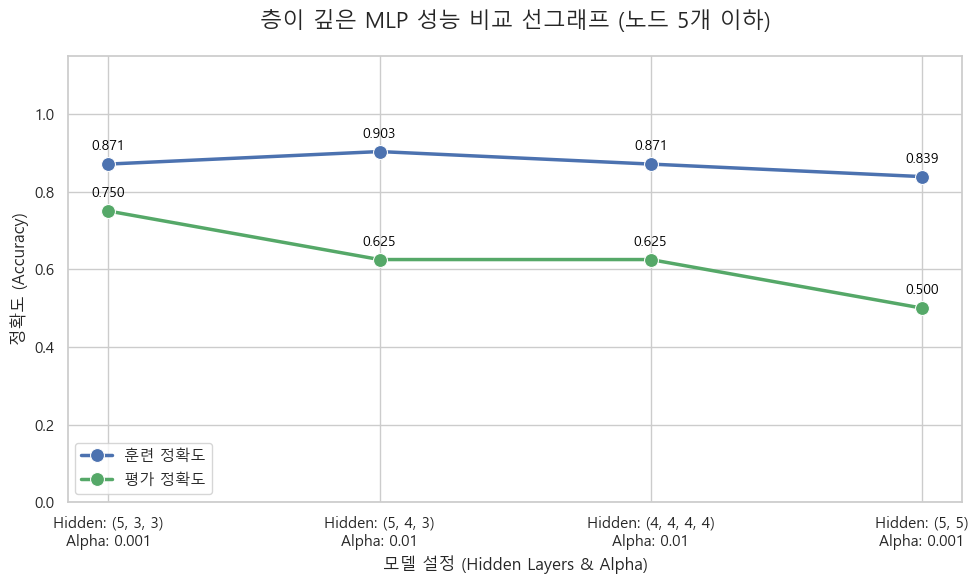

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 깨짐 방지 설정
try:
    plt.rcParams['font.family'] = 'Malgun Gothic' # Windows용 (Mac은 'AppleGothic')
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

# 2. X축 라벨용 '모델 설정' 컬럼 만들기
results_df['모델 설정'] = "Hidden: " + results_df['은닉층 구조(Hidden)'] + "\nAlpha: " + results_df['규제 강도(Alpha)'].astype(str)

# 3. Seaborn 그리기를 위한 데이터 형태 변환
melted_df = results_df.melt(
    id_vars=['모델 설정'], 
    value_vars=['훈련 정확도', '평가 정확도'],
    var_name='평가 종류', 
    value_name='정확도'
)

# 4. 선그래프 세팅
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'

# 5. 선그래프 그리기 (sns.lineplot 사용)
ax = sns.lineplot(
    data=melted_df, 
    x='모델 설정', 
    y='정확도', 
    hue='평가 종류', 
    marker='o',          # 각 데이터 위치에 동그라미 마커 표시
    linewidth=2.5,       # 선 두께
    markersize=10,       # 마커 크기
    palette=['#4C72B0', '#55A868']
)

# 6. 제목 및 축 디자인
plt.title('층이 깊은 MLP 성능 비교 선그래프 (노드 5개 이하)', fontsize=16, pad=20)
plt.xlabel('모델 설정 (Hidden Layers & Alpha)', fontsize=12)
plt.ylabel('정확도 (Accuracy)', fontsize=12)
plt.ylim(0, 1.15) # 글씨가 잘리지 않게 Y축 상단 공간 확보
plt.legend(title='', fontsize=11, loc='lower left')

# 7. 선그래프 마커(점) 위에 수치 텍스트 달아주기
for line in ax.lines:
    for x, y_val in zip(line.get_xdata(), line.get_ydata()):
        # 유효한 숫자일 때만 표기
        if pd.notna(y_val):
            ax.annotate(f"{y_val:.3f}", 
                        (x, y_val), 
                        textcoords="offset points", 
                        xytext=(0, 10), # 점 위치에서 위로 10만큼 떨어져서 표시
                        ha='center', 
                        fontsize=10, 
                        color='black')

# 8. 출력
plt.tight_layout()
plt.show()

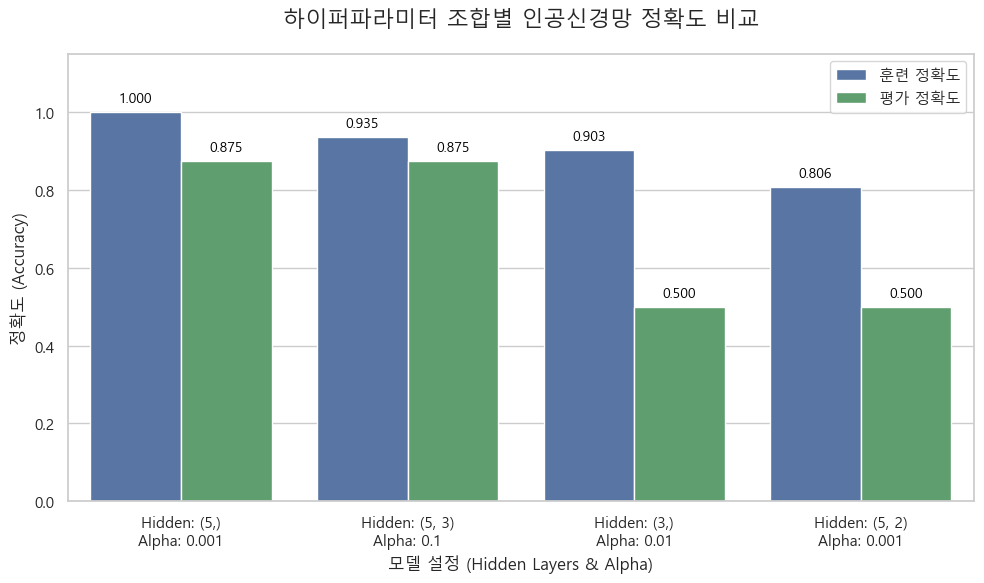

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

# 1. 그래프의 X축에 들어갈 이름 만들기 (은닉층과 알파 값을 합침)
# 예: "Hidden: (5,)\nAlpha: 0.001" 형태로 줄바꿈하여 라벨 생성
results_df['모델 설정'] = "Hidden: " + results_df['은닉층 구조(Hidden)'] + "\nAlpha: " + results_df['규제 강도(Alpha)'].astype(str)

# 2. Seaborn 라이브러리로 쉽게 그리기 위해 데이터를 '긴 형태(Melt)'로 변환
melted_df = results_df.melt(
    id_vars=['모델 설정'], 
    value_vars=['훈련 정확도', '평가 정확도'],
    var_name='평가 종류', 
    value_name='정확도'
)

# 3. 그래프 크기 및 디자인 설정
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # 테마 변경 후 폰트 재설정

# 4. 막대 그래프 그리기 (파란색: 훈련, 초록색: 평가)
ax = sns.barplot(
    data=melted_df, 
    x='모델 설정', 
    y='정확도', 
    hue='평가 종류', 
    palette=['#4C72B0', '#55A868']
)

# 5. 그래프 세부 설정 (제목, 축 이름 등)
plt.title('하이퍼파라미터 조합별 인공신경망 정확도 비교', fontsize=16, pad=20)
plt.xlabel('모델 설정 (Hidden Layers & Alpha)', fontsize=12)
plt.ylabel('정확도 (Accuracy)', fontsize=12)
plt.ylim(0, 1.15) # 막대 위 텍스트 공간을 위해 Y축 여백 확보
plt.legend(title='', fontsize=11, loc='upper right')

# 6. 막대 그래프 위에 정확도 숫자 표기하기
for p in ax.patches:
    height = p.get_height()
    if height > 0: # 값이 있는 경우에만 텍스트 표시
        ax.annotate(f"{height:.3f}", 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', 
                    xytext=(0, 5), textcoords='offset points')

# 7. 레이아웃 겹침 방지 및 그래프 출력
plt.tight_layout()
plt.show()


In [49]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from IPython.display import display

# 테스트할 하이퍼파라미터 조합 세팅 (은닉층 구조와 Alpha 값 변화)
configs = [
    {'hidden': (10,), 'alpha': 0.001},
    {'hidden': (50,), 'alpha': 0.01},
    {'hidden': (10, 5), 'alpha': 0.1},
    {'hidden': (10, 5), 'alpha': 0.001}
]

results = []

print("▶ 모델 학습 및 하이퍼파라미터 성능 비교 시작...\n")

# 설정한 조합(configs)을 하나씩 꺼내어 모델을 만들고 평가합니다.
for cfg in configs:
    # 하이퍼파라미터를 바꿔가며 새로운 인공신경망 모델 생성
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden'], 
        alpha=cfg['alpha'], 
        solver='lbfgs',    # 39개의 소규모 데이터에 가장 적합한 최적화 알고리즘
        max_iter=2000, 
        random_state=42
    )
    
    # 모델 학습 (앞 단계에서 선택된 핵심 피처만 포함된 X_train_selected 사용)
    mlp.fit(X_train_selected, y_train)
    
    # 과적합 여부를 확인하기 위해 훈련/테스트 정확도를 각각 채점
    train_acc = mlp.score(X_train_selected, y_train)
    test_acc = mlp.score(X_test_selected, y_test)
    
    # 결과를 딕셔너리 형태로 리스트에 저장
    results.append({
        '은닉층 구조(Hidden)': str(cfg['hidden']), 
        '규제 강도(Alpha)': cfg['alpha'], 
        '훈련 정확도(Train)': train_acc,
        '평가 정확도(Test)': test_acc
    })

# 결과를 DataFrame(표)으로 변환하고 '평가 정확도'가 높은 순서대로 정렬
results_df = pd.DataFrame(results).sort_values(by='평가 정확도(Test)', ascending=False)

print("📊 [하이퍼파라미터 조합별성능 비교 결과]")
display(results_df)

▶ 모델 학습 및 하이퍼파라미터 성능 비교 시작...

📊 [하이퍼파라미터 조합별성능 비교 결과]


,은닉층 구조(Hidden),규제 강도(Alpha),훈련 정확도(Train),평가 정확도(Test)
0,"(10,)",0.001,1.000000,0.875
1,"(50,)",0.010,1.000000,0.875
2,"(10, 5)",0.100,0.935484,0.625
3,"(10, 5)",0.001,0.903226,0.625
